In [1]:
import numpy as np
import json
import sys
sys.path.append('../../pysimARG')
from clonal_genealogy import ClonalTree
import ClonalOrigin_pair
from add_mutation import add_mutation
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
mutate_edge = np.array([86, 24, 12, 71, 17, 35, 86, 68, 86, 67]) - 1
mutate_site = np.array([2, 1, 2, 2, 1, 1, 1, 2, 2, 1]) - 1
print(mutate_edge)
print(mutate_site)

In [ ]:
n_mutations = 10
edge_mat = np.array([
    [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 0], [0, 1], [1, 0], [1, 1],
    [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [0, 1], [1, 1], [1, 1], [1, 0], [0, 1],
    [1, 0], [0, 1], [1, 0], [0, 1], [0, 0], [1, 0], [0, 0], [0, 0], [1, 0], [0, 1],
    [1, 0], [1, 0], [1, 1], [1, 0], [0, 0], [0, 0], [1, 1], [0, 1], [0, 0], [0, 1],
    [1, 1], [0, 0], [0, 1], [0, 0], [1, 1], [0, 0], [0, 0], [0, 1], [0, 0], [0, 1],
    [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [0, 0], [0, 1], [0, 0],
    [1, 0], [0, 0], [0, 0], [1, 0], [0, 0], [0, 0], [0, 0], [0, 1], [0, 0], [0, 0],
    [0, 0], [0, 1], [0, 0], [0, 0], [0, 1], [0, 1], [0, 0], [1, 0], [0, 1], [0, 0],
    [0, 1], [1, 0], [1, 1], [0, 0], [1, 1], [0, 0]
])
edge = np.array([
    [11,     7, 0.0205380361],
    [11,     6, 0.0205380361],
    [12,     9, 0.1065758788],
    [12,    10, 0.1065758788],
    [13,    11, 0.0929780739],
    [13,     8, 0.1135161100],
    [14,    13, 0.0958692194],
    [15,    13, 0.0958692194],
    [16,    14, 0.0004732405],
    [16,     3, 0.2098585698],
    [17,     2, 0.2379657492],
    [17,    12, 0.1313898704],
    [18,     5, 0.3753210475],
    [18,    17, 0.1373552983],
    [19,    18, 0.0260884199],
    [19,    15, 0.1920241380],
    [20,     4, 0.4074049540],
    [20,    16, 0.1975463841],
    [21,    20, 0.0866376796],
    [22,    20, 0.0866376796],
    [23,    19, 0.1130066453],
    [24,    19, 0.1130066453],
    [25,     1, 0.5219369723],
    [26,     1, 0.5219369723],
    [27,    25, 0.0276397893],
    [28,    25, 0.0276397893],
    [29,    27, 0.0480855813],
    [30,    27, 0.0480855813],
    [31,    23, 0.1628124462],
    [32,    22, 0.1831859254],
    [33,    21, 0.2351942819],
    [34,    28, 0.1796601539],
    [35,    31, 0.0928147642],
    [36,    32, 0.0408064077],
    [37,    29, 0.3324048253],
    [38,    29, 0.3324048253],
    [36,    33, 0.1794087530],
    [36,    24, 0.4350359634],
    [37,    34, 0.0221257899],
    [37,    26, 0.4302559858],
    [38,    36, 0.0699144183],
    [38,    30, 0.4217041516],
    [39,    37, 0.2057032768],
    [40,    37, 0.2057032768],
    [41,    38, 0.3714460578],
    [41,    35, 0.4607453840],
    [42,    39, 0.2342707552],
    [43,    39, 0.2342707552],
    [44,    42, 0.0725647670],
    [44,    43, 0.0725647670],
    [45,    41, 0.1049452897],
    [46,    41, 0.1049452897],
    [47,    45, 0.0131013756],
    [47,    46, 0.0131013756],
    [48,    47, 0.1257516557],
    [49,    47, 0.1257516557],
    [50,    48, 0.0309186482],
    [50,    40, 0.5076332865],
    [51,    44, 0.2174696896],
    [52,    44, 0.2174696896],
    [53,    50, 0.1199962817],
    [53,    52, 0.1033243565],
    [54,    53, 0.2220233659],
    [55,    53, 0.2220233659],
    [56,    54, 0.0467645207],
    [57,    54, 0.0467645207],
    [58,    51, 0.4153258237],
    [59,    51, 0.4153258237],
    [60,    56, 0.0443991569],
    [61,    56, 0.0443991569],
    [62,    60, 0.2153181544],
    [62,    59, 0.2165037306],
    [63,    58, 0.2847589005],
    [64,    58, 0.2847589005],
    [65,    62, 0.0864440035],
    [65,    49, 0.7658641312],
    [66,    63, 0.0438247398],
    [66,    55, 0.4185617416],
    [67,    65, 0.1558640128],
    [67,    57, 0.5020253276],
    [68,    67, 0.0432566285],
    [68,    66, 0.1734847352],
    [69,    68, 0.2334352476],
    [69,    64, 0.4507447225],
    [70,    69, 1.3084051539],
    [70,    61, 2.0427232007]
])

In [ ]:
node_site = np.zeros(
        (70, 2), dtype=bool
    )

In [ ]:
# Ignore mutations not in the edge material
keep_mutation = []
for i in range(n_mutations):
    if edge_mat[mutate_edge[i], mutate_site[i]]:
        keep_mutation.append(i)

mutate_edge = mutate_edge[keep_mutation]
mutate_site = mutate_site[keep_mutation]

In [ ]:
print(keep_mutation)
print(mutate_edge)
print(mutate_site)

In [ ]:
# Simulate the mutations at every node
# Process edges from last to first (bottom-up in the tree)
for i in range(len(edge) - 1, -1, -1):
    # Get mutations on this edge (sites that have mutations on edge i)
    edge_mutation = mutate_site[mutate_edge == i]

    parent_idx = int(edge[i, 0]) - 1
    child_idx = int(edge[i, 1]) - 1

    # Get parent sequence
    parent_seq = node_site[parent_idx, :].copy()

    # Count mutations at each site (equivalent to R's tabulate)
    flip_counts = np.bincount(edge_mutation, minlength=len(parent_seq))

    # XOR with whether flip count is odd
    parent_seq = np.logical_xor(parent_seq, flip_counts % 2 == 1)

    # Get material range for this edge
    material_range = edge_mat[i, :]

    # Update child node sequence only where there's material
    node_site[child_idx, material_range==True] = parent_seq[material_range==True]

In [ ]:
print(node_site[24, :])

In [ ]:
i = 22
edge_mutation = mutate_site[mutate_edge == i+1]

parent_idx = int(edge[i, 0]) - 1
child_idx = int(edge[i, 1]) - 1

# Get parent sequence
parent_seq = node_site[parent_idx, :].copy()

# Count mutations at each site (equivalent to R's tabulate)
flip_counts = np.bincount(edge_mutation, minlength=len(parent_seq))

# XOR with whether flip count is odd
parent_seq = np.logical_xor(parent_seq, flip_counts % 2 == 1)

# Get material range for this edge
material_range = edge_mat[i, :]

# Update child node sequence only where there's material
node_site[child_idx, material_range==True] = parent_seq[material_range==True]

In [ ]:
edge_mutation

In [ ]:
material_range

In [ ]:
parent_seq[material_range==True]

In [ ]:
node_site[child_idx, material_range==True]

In [ ]:
mutate_edge

In [ ]:
test_node_site = np.array([
    [0, 1], [0, 0], [0, 0], [1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [0, 1],
    [0, 0], [0, 1], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0],
    [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [0, 0], [0, 0], [0, 0], [0, 0],
    [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [0, 0], [0, 1], [0, 0],
    [0, 0], [0, 0], [0, 1], [0, 1], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0],
    [0, 1], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0],
    [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]
])

In [ ]:
test_node_site == node_site

## Test simulations

In [3]:
with open('../../pysimARG/test_data/ARG_data.json', 'r') as f:
    ARG_data = json.load(f)

print(ARG_data)

{'clonal_edge': [[16, 7, 0.0088], [16, 6, 0.0088], [17, 12, 0.0428], [17, 14, 0.0428], [18, 8, 0.0653], [18, 17, 0.0224], [19, 10, 0.0848], [19, 9, 0.0848], [20, 13, 0.1215], [20, 19, 0.0368], [21, 16, 0.1212], [21, 2, 0.13], [22, 4, 0.1438], [22, 21, 0.0138], [23, 3, 0.1507], [23, 5, 0.1507], [24, 18, 0.1373], [24, 22, 0.0587], [25, 23, 0.0601], [25, 15, 0.2108], [26, 1, 0.3124], [26, 24, 0.1099], [27, 26, 0.1091], [27, 20, 0.3], [28, 11, 0.6084], [28, 27, 0.1869], [29, 28, 0.9215], [29, 25, 1.3191]], 'clonal_node': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0088, 0.0428, 0.0653, 0.0848, 0.1215, 0.13, 0.1438, 0.1507, 0.2025, 0.2108, 0.3124, 0.4215, 0.6084, 1.5299], 'ARG_edge': [[16, 5, 0.0006], [17, 5, 0.0006], [18, 15, 0.0008], [19, 15, 0.0008], [20, 1, 0.0012], [21, 1, 0.0012], [22, 10, 0.0024], [23, 10, 0.0024], [24, 12, 0.0063], [25, 12, 0.0063], [26, 7, 0.0088], [26, 6, 0.0088], [27, 9, 0.01], [28, 9, 0.01], [29, 2, 0.0137], [30, 2, 0.0137], [31, 24, 0.009], [31, 25, 0.009],

In [6]:
ARG_data.keys()

dict_keys(['clonal_edge', 'clonal_node', 'ARG_edge', 'ARG_edge_mat', 'ARG_node_height', 'ARG_node_mat', 'ARG_node_clonal', 'ARG_sum_time'])

### Fix input

In [15]:
clonal_tree = ClonalTree(n=15)

In [16]:
clonal_tree.edge = np.array(ARG_data['clonal_edge'])

In [17]:
clonal_tree.node_height = np.array(ARG_data['clonal_node'])

In [18]:
clonal_tree.height = np.max(clonal_tree.node_height)
clonal_tree.length = np.sum(clonal_tree.edge[:, 2])

In [19]:
ARG_result = ClonalOrigin_pair.ARG(clonal_tree, 0.2, 100000, 300, 50)

In [20]:
ARG_result.edge = np.array(ARG_data['ARG_edge'])

In [21]:
ARG_result.edge_mat = np.array(ARG_data['ARG_edge_mat'])

In [22]:
ARG_result.node_height = np.array(ARG_data['ARG_node_height'])

In [23]:
ARG_result.node_mat = np.array(ARG_data['ARG_node_mat'])

In [24]:
ARG_result.node_clonal = np.array(ARG_data['ARG_node_clonal'])

In [25]:
ARG_result.height = np.max(ARG_result.node_height)
ARG_result.length = np.sum(ARG_result.edge[:, 2])

In [26]:
ARG_mutated = add_mutation(ARG_result, 0.2)

In [36]:
mutation_list = []
np.random.seed(100)

for i in range(10000):
    ARG_mutated = add_mutation(ARG_result, 0.2)
    leaf_sites = ARG_mutated[:15, :]
    mutation_list.append(np.sum(leaf_sites[:, 0] | leaf_sites[:, 1]))

    if i % 100 == 0:
        print(f'Completed {i} iterations.')

Completed 0 iterations.
Completed 100 iterations.
Completed 200 iterations.
Completed 300 iterations.
Completed 400 iterations.
Completed 500 iterations.
Completed 600 iterations.
Completed 700 iterations.
Completed 800 iterations.
Completed 900 iterations.
Completed 1000 iterations.
Completed 1100 iterations.
Completed 1200 iterations.
Completed 1300 iterations.
Completed 1400 iterations.
Completed 1500 iterations.
Completed 1600 iterations.
Completed 1700 iterations.
Completed 1800 iterations.
Completed 1900 iterations.
Completed 2000 iterations.
Completed 2100 iterations.
Completed 2200 iterations.
Completed 2300 iterations.
Completed 2400 iterations.
Completed 2500 iterations.
Completed 2600 iterations.
Completed 2700 iterations.
Completed 2800 iterations.
Completed 2900 iterations.
Completed 3000 iterations.
Completed 3100 iterations.
Completed 3200 iterations.
Completed 3300 iterations.
Completed 3400 iterations.
Completed 3500 iterations.
Completed 3600 iterations.
Completed 370

In [37]:
R_data = np.loadtxt('../../pysimARG/test_data/num_mutations.csv', delimiter=",", skiprows=1)
R_data # length, height

array([ 1.,  7.,  5., ..., 15.,  7.,  0.], shape=(10000,))

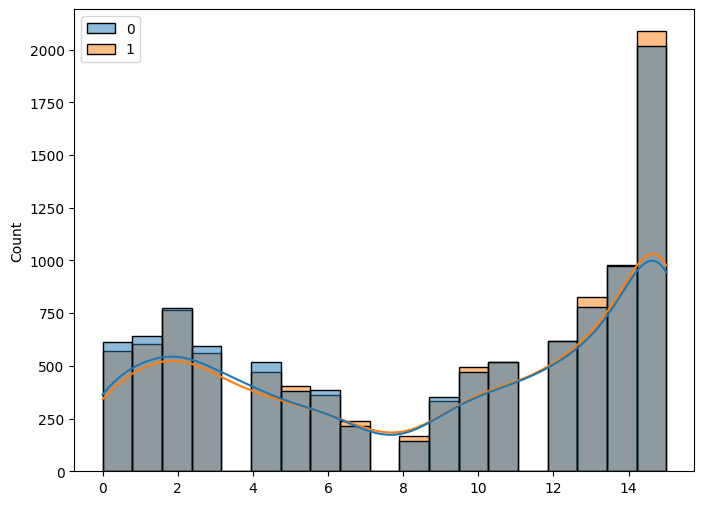

In [38]:
plt.figure(figsize=(8, 6))
sns.histplot([mutation_list, R_data], kde=True) 

plt.show()